# Notebook 17 - Parametric calibration and one-model-day-ahead forecasting

## Exercise 2: event-unaware parametric background

This notebook evaluates the frozen Notebook 16 variance-background equations using observed lagged states. It retains event dates, adds no event indicator or weight, and intentionally excludes Equation (5) from the empirical implementation following Linus's instruction.

## 1. Frozen Notebook 16 contract and N16 → N17 hand-off

`16_primary_specification.csv` is read programmatically as the sole structural authority. N16 has already selected the weekday-normalised implied state, parent sets, and history depths. N17 estimates the corresponding parametric forecasting equations and evaluates their one-model-day-ahead predictions; it does not reopen any N16 retain/drop decision.

The inherited realised-variance equation is:

$$
R_t
=
c_R
+
\beta_1 R_{t-1}
+
\gamma_1 I_{t-1}
+
\varepsilon_t^R.
$$

The inherited implied-variance equation is:

$$
I_t
=
c_I
+
\sum_{j=1}^{12}
\left[
a_j I_{t-j}
+
b_j Q_{t-j}
+
g_j R_{t-j}
\right]
+
\varepsilon_t^I.
$$

Thus the realised target has one lag and excludes Q history; the implied target has 12 lags of its own, Q, and R histories. Expanded and benchmark specifications below remain comparators, not replacements for the frozen N16 primary models.

In [30]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from IPython.display import display, Math

pd.set_option('display.max_columns', 100)
RUN_ID = pd.Timestamp.now(tz='UTC').isoformat()
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Data' / 'processed').exists())
PROCESSED = PROJECT_ROOT / 'Data' / 'processed'
SPEC_PATH = PROCESSED / '16_primary_specification.csv'
PANEL_PATH = PROCESSED / '16_empirical_analysis_panel.csv'
RETURN_SOURCE_PATH = PROCESSED / 'usdjpy_daily_model_panel.csv'
assert SPEC_PATH.exists(), f'Missing frozen contract: {SPEC_PATH}'
assert PANEL_PATH.exists(), f'Missing frozen analysis panel: {PANEL_PATH}'
assert RETURN_SOURCE_PATH.exists(), f'Missing return source needed only for Equation (1): {RETURN_SOURCE_PATH}'
def parse_bool(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if isinstance(value, (int, np.integer)) and value in (0, 1):
        return bool(value)
    text = str(value).strip().lower()
    if text in {'true', '1'}:
        return True
    if text in {'false', '0'}:
        return False
    raise ValueError(f'Cannot parse boolean contract field: {value!r}')

spec = pd.read_csv(SPEC_PATH)
assert len(spec) == 1, 'Notebook 16 primary specification must have one authoritative row'
spec = spec.iloc[0]
RETAIN = {x: parse_bool(spec[x]) for x in ['retain_Q_to_R', 'retain_I_to_R', 'retain_Q_to_I', 'retain_R_to_I']}
CONTRACT_FLAGS = {x: parse_bool(spec[x]) for x in ['event_unaware', 'eventless', 'equation_5_implemented']}
expected = {'iv_specification': 'WEEKDAY_NORM_IV', 'iv_column': 'iv_model_var', 'selected_n': 1, 'selected_m': 12, 'retain_Q_to_R': False, 'retain_I_to_R': True, 'retain_Q_to_I': True, 'retain_R_to_I': True}
for key, value in expected.items():
    actual = spec[key]
    if isinstance(value, bool):
        actual = RETAIN[key] if key in RETAIN else CONTRACT_FLAGS[key]
    elif isinstance(value, int):
        actual = int(actual)
    assert actual == value, f'Frozen Notebook 16 contract discrepancy for {key}: expected {value!r}, found {actual!r}'
assert CONTRACT_FLAGS['event_unaware'] and not CONTRACT_FLAGS['eventless'] and not CONTRACT_FLAGS['equation_5_implemented']
N_ORDER, M_ORDER = int(spec['selected_n']), int(spec['selected_m'])
IV_SPECIFICATION, IV_COLUMN = str(spec['iv_specification']), str(spec['iv_column'])
print(f'Notebook 17 RUN_ID: {RUN_ID}')
print(f'Frozen upstream contract loaded: {IV_SPECIFICATION}; {IV_COLUMN}; n={N_ORDER}; m={M_ORDER}')


Notebook 17 RUN_ID: 2026-08-18T17:21:43.040270+00:00
Frozen upstream contract loaded: WEEKDAY_NORM_IV; iv_model_var; n=1; m=12


## 2. Canonical panel and forecast chronology

The frozen Notebook 16 analysis panel supplies the modelling data and `sample_split` labels directly. TRAIN calibrates validation forecasts; after those diagnostics, TRAIN plus VALIDATION calibrates fixed-coefficient TEST forecasts. TEST remains an out-of-sample evaluation set: it does not select parent variables, lag depths, transformations, or the primary specification. No split is reconstructed and no observations are shuffled.

VALIDATION forecasts are out-of-sample with respect to coefficient calibration because their coefficients are estimated on TRAIN. However, VALIDATION forms part of the wider model-development process because N16 used it to confirm the frozen predictive structure. This is normal validation-set usage, not leakage. TEST therefore remains the untouched final evaluation sample for the full modelling pipeline:

$$
\text{TRAIN}
\rightarrow
\text{VALIDATION}
$$

followed by the frozen specification and:

$$
\text{TRAIN + VALIDATION}
\rightarrow
\text{TEST}.
$$

Lag construction occurs before split filtering, so a forecast target at time t can use observed states dated t-1 or earlier. Those past states belong to the available information set:

$$
\mathcal F_{t-1}.
$$

The fitted forecast is therefore:

$$
\widehat Y_t
=
E\left[Y_t\mid\mathcal F_{t-1}\right].
$$

Using observed Q, R, and I at t-1, t-2, and earlier is legitimate historical information. Leakage would mean including the target at t, using a later observation, or selecting the specification after inspecting TEST results. The checks below make the lag-only construction and pre-TEST calibration visible.

The parent-directory project lookup is retained deliberately so the notebook can run from either the project root or its notebook directory without an absolute path.

In [31]:
panel = pd.read_csv(PANEL_PATH, parse_dates=['date', 'model_day']).sort_values('model_day').reset_index(drop=True)
return_source = pd.read_csv(RETURN_SOURCE_PATH, parse_dates=['model_day'], usecols=['model_day', 'within_session_log_return'])
panel = panel.merge(return_source, on='model_day', how='left', validate='one_to_one')
required = {'date', 'model_day', 'sample_split', 'squared_return', 'realised_variance_ann_252', 'iv_ann_var', 'iv_model_var'}
assert required.issubset(panel.columns), f'Panel missing: {required - set(panel.columns)}'
assert panel['model_day'].is_unique and panel['model_day'].is_monotonic_increasing
assert set(panel['sample_split']) == {'train', 'validation', 'test'}
split_dates = panel.groupby('sample_split')['model_day'].agg(['min', 'max', 'count'])
assert split_dates.loc['train', 'max'] < split_dates.loc['validation', 'min'] < split_dates.loc['test', 'min']
# The frozen Notebook 16 panel remains primary; this one-to-one merge supplies signed r only for Equation (1).
panel['r'] = pd.to_numeric(panel['within_session_log_return'], errors='coerce')
panel['Q'] = pd.to_numeric(panel['squared_return'], errors='coerce')
panel['R'] = pd.to_numeric(panel['realised_variance_ann_252'], errors='coerce')
panel['I'] = pd.to_numeric(panel[IV_COLUMN], errors='coerce')
assert np.isfinite(panel.loc[panel['sample_split'].isin(['train', 'validation', 'test']), 'I']).any()
assert np.allclose(panel.loc[panel['Q'].notna(), 'Q'], panel.loc[panel['Q'].notna(), 'squared_return'])
for state in ['Q', 'R', 'I']:
    for lag in range(1, M_ORDER + 1):
        panel[f'{state}_lag{lag}'] = panel[state].shift(lag)
print(split_dates)
display(panel[['date', 'model_day', 'sample_split', 'Q', 'R', 'iv_ann_var', 'I']].head())


                    min        max  count
sample_split                             
test         2021-11-15 2026-07-02   1209
train        2003-05-05 2017-03-27   3626
validation   2017-03-28 2021-11-12   1209


,date,model_day,sample_split,Q,R,iv_ann_var,I
0,2003-05-05,2003-05-05,train,0.000008,0.001614,NaN,NaN
1,2003-05-06,2003-05-06,train,0.000085,0.005657,0.011025,0.010470
2,2003-05-07,2003-05-07,train,0.000097,0.008635,0.022500,0.019376
3,2003-05-08,2003-05-08,train,0.000019,0.007664,0.028900,0.021990
4,2003-05-09,2003-05-09,train,0.000008,0.003494,NaN,NaN


## 3. States, units, model clock, and OLS calibration

Q is squared aggregate daily return rather than realised variance. Within-session realised variance sums squared intraday increments, whereas Q also contains hourly cross-products. The project uses a one-model-day annualisation convention of 252 and treats variance as a rate. The weekday-normalised implied state I is stored in `iv_model_var`; its raw benchmark is `iv_ann_var`.

Each non-persistence parametric model is estimated using the generic linear representation:

$$
y
=
X\beta
+
\varepsilon.
$$

For explanatory purposes, the OLS estimator is:

$$
\widehat{\beta}
=
\left(X^\top X\right)^{-1}X^\top y.
$$

The production code uses the existing numerical OLS implementation rather than manually inverting a matrix. For the realised primary model, the design row is:

$$
x_t^R
=
\left[1, R_{t-1}, I_{t-1}\right],
$$

which gives:

$$
\widehat R_t
=
\widehat c_R
+
\widehat\beta_1 R_{t-1}
+
\widehat\gamma_1 I_{t-1}.
$$

The 12-lag implied primary forecast is:

$$
\widehat I_t
=
\widehat c_I
+
\sum_{j=1}^{12}
\left[
\widehat a_j I_{t-j}
+
\widehat b_j Q_{t-j}
+
\widehat g_j R_{t-j}
\right].
$$

The model definitions immediately below map these terms directly to the named lag columns.

In [32]:
R_MODELS = {
    'R_PERSISTENCE': {'target': 'R', 'features': None, 'persistence': 'R_lag1'},
    'R_AR1': {'target': 'R', 'features': ['R_lag1']},
    'R_AR1_Q': {'target': 'R', 'features': ['Q_lag1', 'R_lag1']},
    'R_PRIMARY_AR1_IV': {'target': 'R', 'features': ['R_lag1', 'I_lag1']},
    'R_EXPANDED_Q_R_IV': {'target': 'R', 'features': ['Q_lag1', 'R_lag1', 'I_lag1']},
}
I_LAGS = [f'I_lag{j}' for j in range(1, M_ORDER + 1)]
Q_LAGS = [f'Q_lag{j}' for j in range(1, M_ORDER + 1)]
R_LAGS = [f'R_lag{j}' for j in range(1, M_ORDER + 1)]
I_MODELS = {
    'I_PERSISTENCE': {'target': 'I', 'features': None, 'persistence': 'I_lag1'},
    'I_AR12': {'target': 'I', 'features': I_LAGS},
    'I_AR12_Q': {'target': 'I', 'features': I_LAGS + Q_LAGS},
    'I_AR12_R': {'target': 'I', 'features': I_LAGS + R_LAGS},
    'I_PRIMARY_FULL_12': {'target': 'I', 'features': I_LAGS + Q_LAGS + R_LAGS},
}
MODELS = {**R_MODELS, **I_MODELS}
FAMILY_FEATURES = {'R': ['Q_lag1', 'R_lag1', 'I_lag1'], 'I': Q_LAGS + R_LAGS + I_LAGS}
assert 'Q_lag1' not in R_MODELS['R_PRIMARY_AR1_IV']['features'] and RETAIN['retain_Q_to_R'] is False
assert set(Q_LAGS).issubset(I_MODELS['I_PRIMARY_FULL_12']['features']) and set(R_LAGS).issubset(I_MODELS['I_PRIMARY_FULL_12']['features'])
assert N_ORDER == 1 and M_ORDER == 12

def assert_lagged_features(target, features):
    for feature in features:
        state, lag_text = feature.rsplit('_lag', maxsplit=1)
        assert state in {'Q', 'R', 'I'}
        assert int(lag_text) >= 1, f'Contemporaneous predictor is not allowed: {feature}'
        assert feature != target, f'Contemporaneous target is not allowed: {feature}'

for model_name, model_definition in MODELS.items():
    assert_lagged_features(model_definition['target'], model_definition.get('features') or [])

def family_rows(frame, target, splits=None, before=None):
    candidate_rows = frame.copy()
    if splits is not None:
        candidate_rows = candidate_rows.loc[candidate_rows.sample_split.isin(splits)]
    if before is not None:
        candidate_rows = candidate_rows.loc[candidate_rows.model_day.lt(before)]
    required_columns = [target] + FAMILY_FEATURES[target]
    finite_rows = np.isfinite(candidate_rows[required_columns]).all(axis=1)
    return candidate_rows.loc[finite_rows].copy()

def fit_model(frame, name, splits=None, before=None):
    model_definition = MODELS[name]
    target = model_definition['target']
    training_rows = family_rows(frame, target, splits, before)
    feature_columns = model_definition.get('features')
    if feature_columns is None:
        return {'name': name, 'target': target, 'features': [], 'sample': training_rows, 'fit': None}
    design_matrix = sm.add_constant(training_rows[feature_columns], has_constant='add')
    response = training_rows[target]
    fitted_model = sm.OLS(response, design_matrix).fit()
    return {'name': name, 'target': target, 'features': feature_columns, 'sample': training_rows, 'fit': fitted_model}

def forecast(fitted, rows):
    model_definition = MODELS[fitted['name']]
    if fitted['fit'] is None:
        return rows[model_definition['persistence']].to_numpy(float)
    feature_columns = fitted['features']
    design_matrix = sm.add_constant(rows[feature_columns], has_constant='add')
    return np.asarray(fitted['fit'].predict(design_matrix), dtype=float)

def coefficient_rows(fitted, calibration_split):
    if fitted['fit'] is None:
        return pd.DataFrame()
    fitted_model = fitted['fit']
    confidence_intervals = fitted_model.conf_int()
    coefficient_table = pd.DataFrame({
        'predictor': ['const'] + fitted['features'],
        'coefficient': fitted_model.params,
        'std_error': fitted_model.bse,
        't_stat': fitted_model.tvalues,
        'p_value': fitted_model.pvalues,
        'ci_lower': confidence_intervals.iloc[:, 0].to_numpy(),
        'ci_upper': confidence_intervals.iloc[:, 1].to_numpy(),
    })
    coefficient_table['model'] = fitted['name']
    coefficient_table['target'] = fitted['target']
    coefficient_table['calibration_split'] = calibration_split
    coefficient_table['calibration_n'] = int(fitted_model.nobs)
    return coefficient_table

def residual_scale_row(fitted, calibration_split):
    if fitted['fit'] is None:
        return None
    fitted_model = fitted['fit']
    residual_sum_squares = float(np.sum(fitted_model.resid ** 2))
    observation_count = int(fitted_model.nobs)
    parameter_count = int(len(fitted_model.params))
    return {
        'model': fitted['name'],
        'target': fitted['target'],
        'calibration_split': calibration_split,
        'ssr': residual_sum_squares,
        'nobs': observation_count,
        'parameter_count': parameter_count,
        'residual_standard_error_conventional': math.sqrt(fitted_model.mse_resid),
        'residual_scale_mle': math.sqrt(residual_sum_squares / observation_count),
    }

def forecast_records(fits, split, scheme):
    forecast_frames = []
    for target, model_names in [('R', list(R_MODELS)), ('I', list(I_MODELS))]:
        evaluation_rows = family_rows(panel, target, [split])
        target_dates = evaluation_rows.model_day.to_numpy()
        previous_dates = panel.loc[evaluation_rows.index - 1, 'model_day'].to_numpy()
        assert np.all(previous_dates < target_dates)
        for name in model_names:
            fitted_forecast = forecast(fits[name], evaluation_rows)
            assert len(fitted_forecast) == len(evaluation_rows)
            assert np.array_equal(target_dates, evaluation_rows.model_day.to_numpy())
            forecast_frames.append(pd.DataFrame({
                'model_day': target_dates,
                'sample_split': split,
                'forecast_scheme': scheme,
                'target': target,
                'model': name,
                'actual': evaluation_rows[target].to_numpy(float),
                'raw_forecast': fitted_forecast,
            }))
    records = pd.concat(forecast_frames, ignore_index=True)
    records['forecast_error'] = records.actual - records.raw_forecast
    records['positive_forecast'] = records.raw_forecast.gt(0)
    return records

def calculate_rmse(forecast_error):
    squared_forecast_error = np.square(forecast_error)
    return math.sqrt(np.mean(squared_forecast_error))

def metric_table(records):
    metric_rows = []
    grouping_columns = ['forecast_scheme', 'sample_split', 'target']
    for (scheme, split, target), target_records in records.groupby(grouping_columns, sort=False):
        persistence_model = 'R_PERSISTENCE' if target == 'R' else 'I_PERSISTENCE'
        persistence_records = target_records.loc[
            target_records.model.eq(persistence_model),
            ['model_day', 'raw_forecast'],
        ].rename(columns={'raw_forecast': 'persistence'})
        for model, model_records in target_records.groupby('model', sort=False):
            comparison_rows = model_records.merge(
                persistence_records,
                on='model_day',
                validate='one_to_one',
            )
            actual = comparison_rows.actual.to_numpy(float)
            raw_forecast = comparison_rows.raw_forecast.to_numpy(float, copy=True)
            persistence_forecast = comparison_rows.persistence.to_numpy(float, copy=True)
            assert np.array_equal(comparison_rows.raw_forecast.to_numpy(float), raw_forecast, equal_nan=True)

            forecast_error = actual - raw_forecast
            persistence_error = actual - persistence_forecast
            valid_qlike = (actual > 0) & (raw_forecast > 0)
            positive_actual = actual > 0
            floored_for_penalty = np.maximum(raw_forecast, 1e-12)
            assert np.array_equal(comparison_rows.raw_forecast.to_numpy(float), raw_forecast, equal_nan=True)

            calibration_n = int(len(fits_for_scheme[scheme][model]['sample'])) if scheme in fits_for_scheme else np.nan
            metric_rows.append({
                'forecast_scheme': scheme,
                'sample_split': split,
                'target': target,
                'model': model,
                'calibration_n': calibration_n,
                'oos_n': len(comparison_rows),
                'MAE': np.mean(np.abs(forecast_error)),
                'RMSE': calculate_rmse(forecast_error),
                'mean_error': np.mean(forecast_error),
                'OOS_R2_vs_persistence': 1 - np.sum(forecast_error ** 2) / np.sum(persistence_error ** 2),
                'qlike_positive_only': np.mean(actual[valid_qlike] / raw_forecast[valid_qlike] - np.log(actual[valid_qlike] / raw_forecast[valid_qlike]) - 1) if valid_qlike.any() else np.nan,
                'qlike_positive_n': int(valid_qlike.sum()),
                'qlike_positive_fraction': float(valid_qlike.mean()),
                'qlike_floored_penalty': np.mean(actual[positive_actual] / floored_for_penalty[positive_actual] - np.log(actual[positive_actual] / floored_for_penalty[positive_actual]) - 1) if positive_actual.any() else np.nan,
                'n_positive_forecasts': int((raw_forecast > 0).sum()),
                'n_zero_forecasts': int((raw_forecast == 0).sum()),
                'n_negative_forecasts': int((raw_forecast < 0).sum()),
                'positive_fraction': float((raw_forecast > 0).mean()),
            })
    return pd.DataFrame(metric_rows)

def weighted_mu(frame, splits):
    x = frame.loc[frame.sample_split.isin(splits) & np.isfinite(frame[['r', 'R']]).all(axis=1) & frame.R.gt(0), ['r', 'R']]
    assert len(x) > 0
    return float((x.r / x.R).sum() / (1 / x.R).sum()), int(len(x))

print('Common eligible rows by split:')
display(pd.DataFrame({target: family_rows(panel, target).groupby('sample_split').size() for target in ['R', 'I']}))


Common eligible rows by split:


,R,I
sample_split,,
test,1182,1071
train,3005,2226
validation,1181,1087


# Part A - Realised variance: calibration, benchmarks, and RMSE

| Target | Implemented model | Role |
|---|---|---|
| R | R_PERSISTENCE | Uses the most recent realised state; it is the basic persistence benchmark. |
| R | R_AR1 | Tests the target's own one-lag history. |
| R | R_AR1_Q | Isolates the addition of lagged Q to own history. |
| R | R_PRIMARY_AR1_IV | Frozen N16 primary model: lagged R and I, with Q excluded. |
| R | R_EXPANDED_Q_R_IV | Sensitivity comparator that adds Q back; it does not redefine the primary model. |
| I | I_PERSISTENCE | Uses the most recent implied state; it is the basic persistence benchmark. |
| I | I_AR12 | Tests whether own 12-lag implied history is sufficient. |
| I | I_AR12_Q and I_AR12_R | Add one retained cross-history block at a time. |
| I | I_PRIMARY_FULL_12 | Frozen N16 primary model with 12 lags of I, Q, and R. |

All fitted models within a target family use the same finite comparison rows. The forecast error and RMSE are:

$$
e_t
=
Y_t
-
\widehat Y_t,
$$

$$
\mathrm{RMSE}
=
\sqrt{\frac{1}{N}\sum_{t=1}^{N}\left(Y_t-\widehat Y_t\right)^2}.
$$

The metric function below computes this quantity directly from raw actual-minus-forecast errors. It does not alter forecasts.

In [33]:
train_fits = {name: fit_model(panel, name, ['train']) for name in MODELS}
fits_for_scheme = {'fixed_train': train_fits}
assert len({len(train_fits[name]['sample']) for name in R_MODELS if train_fits[name]['fit'] is not None}) == 1
assert len({len(train_fits[name]['sample']) for name in I_MODELS if train_fits[name]['fit'] is not None}) == 1
validation_forecasts = forecast_records(train_fits, 'validation', 'fixed_train')
validation_metrics = metric_table(validation_forecasts)
mu_validation, mu_validation_n = weighted_mu(panel, ['train'])
train_coefficients = pd.concat([coefficient_rows(x, 'train') for x in train_fits.values() if x['fit'] is not None], ignore_index=True)
train_scales = pd.DataFrame([x for x in (residual_scale_row(v, 'train') for v in train_fits.values()) if x is not None])
print(f'Common TRAIN calibration n: realised={len(train_fits["R_PRIMARY_AR1_IV"]["sample"])}, implied={len(train_fits["I_PRIMARY_FULL_12"]["sample"])}')
display(validation_metrics.loc[validation_metrics.target.eq('R')])


Common TRAIN calibration n: realised=3005, implied=2226


,forecast_scheme,sample_split,target,model,calibration_n,oos_n,MAE,RMSE,mean_error,OOS_R2_vs_persistence,qlike_positive_only,qlike_positive_n,qlike_positive_fraction,qlike_floored_penalty,n_positive_forecasts,n_zero_forecasts,n_negative_forecasts,positive_fraction
0,fixed_train,validation,R,R_PERSISTENCE,3005,1181,0.002889,0.007810,-0.000018,0.000000,0.425350,1181,1.0,0.425350,1181,0,0,1.0
1,fixed_train,validation,R,R_AR1,3005,1181,0.005497,0.008016,-0.004056,-0.053386,0.518451,1181,1.0,0.518451,1181,0,0,1.0
2,fixed_train,validation,R,R_AR1_Q,3005,1181,0.005444,0.007954,-0.004037,-0.037279,0.514308,1181,1.0,0.514308,1181,0,0,1.0
3,fixed_train,validation,R,R_PRIMARY_AR1_IV,3005,1181,0.003304,0.006518,-0.001574,0.303381,0.323900,1181,1.0,0.323900,1181,0,0,1.0
4,fixed_train,validation,R,R_EXPANDED_Q_R_IV,3005,1181,0.003277,0.006498,-0.001572,0.307825,0.321499,1181,1.0,0.321499,1181,0,0,1.0


## Validation protocol and residual scale

Validation uses TRAIN-only coefficients and observed lagged states dated no later than the prior model day. Forecasts are direct rather than recursive. After this pre-TEST diagnostic, the same frozen specifications are fit once on TRAIN plus VALIDATION and held fixed for TEST. The notebook reports both conventional OLS residual standard error and the Gaussian maximum-likelihood residual scale; the coefficient estimates are identical.

In [34]:
final_fits = {name: fit_model(panel, name, ['train', 'validation']) for name in MODELS}
fits_for_scheme['fixed_train_validation'] = final_fits
assert len({len(final_fits[name]['sample']) for name in R_MODELS if final_fits[name]['fit'] is not None}) == 1
assert len({len(final_fits[name]['sample']) for name in I_MODELS if final_fits[name]['fit'] is not None}) == 1
test_forecasts = forecast_records(final_fits, 'test', 'fixed_train_validation')
test_metrics = metric_table(test_forecasts)
mu_test, mu_test_n = weighted_mu(panel, ['train', 'validation'])
test_coefficients = pd.concat([coefficient_rows(x, 'train_plus_validation') for x in final_fits.values() if x['fit'] is not None], ignore_index=True)
test_scales = pd.DataFrame([x for x in (residual_scale_row(v, 'train_plus_validation') for v in final_fits.values()) if x is not None])
assert final_fits['R_PRIMARY_AR1_IV']['sample'].model_day.max() < panel.loc[panel.sample_split.eq('test'), 'model_day'].min()
print(f'Common TRAIN+VALIDATION calibration n: realised={len(final_fits["R_PRIMARY_AR1_IV"]["sample"])}, implied={len(final_fits["I_PRIMARY_FULL_12"]["sample"])}')
display(test_metrics.loc[test_metrics.target.eq('R')])


Common TRAIN+VALIDATION calibration n: realised=4186, implied=3313


,forecast_scheme,sample_split,target,model,calibration_n,oos_n,MAE,RMSE,mean_error,OOS_R2_vs_persistence,qlike_positive_only,qlike_positive_n,qlike_positive_fraction,qlike_floored_penalty,n_positive_forecasts,n_zero_forecasts,n_negative_forecasts,positive_fraction
0,fixed_train_validation,test,R,R_PERSISTENCE,4186,1182,0.007978,0.021240,0.000006,0.000000,0.794778,1182,1.0,0.794778,1182,0,0,1.0
1,fixed_train_validation,test,R,R_AR1,4186,1182,0.006849,0.016870,0.000306,0.369188,0.463711,1182,1.0,0.463711,1182,0,0,1.0
2,fixed_train_validation,test,R,R_AR1_Q,4186,1182,0.006862,0.016835,0.000266,0.371757,0.460001,1182,1.0,0.460001,1182,0,0,1.0
3,fixed_train_validation,test,R,R_PRIMARY_AR1_IV,4186,1182,0.005551,0.015028,0.001101,0.499442,0.327715,1182,1.0,0.327715,1182,0,0,1.0
4,fixed_train_validation,test,R,R_EXPANDED_Q_R_IV,4186,1182,0.005551,0.015003,0.001068,0.501105,0.325666,1182,1.0,0.325666,1182,0,0,1.0


# Final calibrated parametric background

**Final calibration: TRAIN + VALIDATION fit used for fixed-coefficient TEST forecasting.** The displayed values below come directly from the fitted model objects used to produce the untouched TEST forecasts. They characterise the calibrated parametric background; validation and test metrics separately assess out-of-sample forecasting performance.

## Primary realised-variance calibration

The one-model-day-ahead forecast from the frozen primary realised equation is

$$
\widehat R_{t\mid t-1}
=
\widehat c_R
+
\widehat\beta_1 R_{t-1}
+
\widehat\gamma_1 I_{t-1}.
$$

The intercept is the conditional baseline when both lagged states are zero; the lagged-realised coefficient measures realised-variance persistence, and the lagged weekday-normalised implied coefficient is its incremental association with next-day realised variance. These are conditional predictive coefficients, not interventionist causal effects.

In [35]:
FINAL_CALIBRATION_LABEL = 'TRAIN + VALIDATION fit used for fixed-coefficient TEST forecasting'
final_realised = final_fits['R_PRIMARY_AR1_IV']['fit']
final_implied = final_fits['I_PRIMARY_FULL_12']['fit']
assert final_realised is not None and final_implied is not None

realised_names = ['const', 'R_lag1', 'I_lag1']
realised_labels = ['c_R', 'beta_1', 'gamma_1']
realised_parameter_table = pd.DataFrame({
    'Parameter': realised_labels,
    'Predictor': realised_names,
    'Estimate': final_realised.params.loc[realised_names].to_numpy(),
    'Std. Error': final_realised.bse.loc[realised_names].to_numpy(),
    't-stat': final_realised.tvalues.loc[realised_names].to_numpy(),
    'p-value': final_realised.pvalues.loc[realised_names].to_numpy(),
})
assert np.allclose(realised_parameter_table['Estimate'], test_coefficients.loc[test_coefficients.model.eq('R_PRIMARY_AR1_IV')].set_index('predictor').loc[realised_names, 'coefficient'])
display(realised_parameter_table.style.format({'Estimate': '{:.6f}', 'Std. Error': '{:.6f}', 't-stat': '{:.3f}', 'p-value': '{:.3g}'}))

c_r, beta_r, gamma_r = realised_parameter_table['Estimate'].to_numpy()
print('Final calibration:', FINAL_CALIBRATION_LABEL)
print(f'Numerical realised equation: R_hat_t = {c_r:.6f} + {beta_r:.6f} R_(t-1) + {gamma_r:.6f} I_(t-1)')

realised_scale_table = test_scales.loc[test_scales.model.eq('R_PRIMARY_AR1_IV'), ['residual_standard_error_conventional', 'residual_scale_mle']].rename(columns={'residual_standard_error_conventional': 'Conventional OLS residual SE', 'residual_scale_mle': 'Gaussian residual-scale MLE'})
display(realised_scale_table.style.format('{:.6f}'))


,Parameter,Predictor,Estimate,Std. Error,t-stat,p-value
0,c_R,const,0.002880,0.000266,10.826,5.86e-27
1,beta_1,R_lag1,0.117891,0.016077,7.333,2.69e-13
2,gamma_1,I_lag1,0.394001,0.012995,30.320,1.03e-182


Final calibration: TRAIN + VALIDATION fit used for fixed-coefficient TEST forecasting
Numerical realised equation: R_hat_t = 0.002880 + 0.117891 R_(t-1) + 0.394001 I_(t-1)


,Conventional OLS residual SE,Gaussian residual-scale MLE
2,0.014371,0.014366


The final realised calibration has positive persistence through lagged realised variance and a positive lagged-IV coefficient. Under conventional OLS inference the lagged-IV coefficient is clearly distinguishable from zero, and its positive sign aligns with Notebook 16's retained positive predictive relationship. The intercept is a conditional baseline; coefficient magnitude should be interpreted in the common annual variance-rate units, not as a causal effect.

## Primary implied-variance calibration

The one-model-day-ahead forecast from the frozen primary implied equation is

$$
\widehat I_{t\mid t-1}
=
\widehat c_I
+
\sum_{j=1}^{12}
\left(
\widehat\alpha_jQ_{t-j}
+
\widehat\beta_jR_{t-j}
+
\widehat\gamma_jI_{t-j}
\right).
$$

The lag-by-lag table provides a compact view of the parameter estimates. The complete numerical fitted equations are displayed below in separate Q, R, and I blocks.

In [36]:
def fitted_value(result, predictor):
    assert predictor in result.params.index
    return float(result.params.loc[predictor])

lag_index = list(range(1, M_ORDER + 1))
implied_lag_table = pd.DataFrame({
    'Lag j': lag_index,
    'alpha_j on Q': [fitted_value(final_implied, f'Q_lag{j}') for j in lag_index],
    'beta_j on R': [fitted_value(final_implied, f'R_lag{j}') for j in lag_index],
    'gamma_j on I': [fitted_value(final_implied, f'I_lag{j}') for j in lag_index],
})
assert len(implied_lag_table) == M_ORDER == 12
assert implied_lag_table['Lag j'].tolist() == list(range(1, 13))
assert np.allclose(implied_lag_table['alpha_j on Q'], [final_implied.params[f'Q_lag{j}'] for j in lag_index])
assert np.allclose(implied_lag_table['beta_j on R'], [final_implied.params[f'R_lag{j}'] for j in lag_index])
assert np.allclose(implied_lag_table['gamma_j on I'], [final_implied.params[f'I_lag{j}'] for j in lag_index])

exported_primary_implied = test_coefficients.loc[test_coefficients.model.eq('I_PRIMARY_FULL_12')].set_index('predictor')['coefficient']
for block, column in [('Q', 'alpha_j on Q'), ('R', 'beta_j on R'), ('I', 'gamma_j on I')]:
    assert np.allclose(implied_lag_table[column], [exported_primary_implied[f'{block}_lag{j}'] for j in lag_index])

implied_intercept = fitted_value(final_implied, 'const')
print('Final calibration:', FINAL_CALIBRATION_LABEL)
print(f'Primary implied intercept c_I = {implied_intercept:.6f}')
display(implied_lag_table.style.format({'alpha_j on Q': '{:.6f}', 'beta_j on R': '{:.6f}', 'gamma_j on I': '{:.6f}'}))

implied_scale_table = test_scales.loc[test_scales.model.eq('I_PRIMARY_FULL_12'), ['residual_standard_error_conventional', 'residual_scale_mle']].rename(columns={'residual_standard_error_conventional': 'Conventional OLS residual SE', 'residual_scale_mle': 'Gaussian residual-scale MLE'})
display(implied_scale_table.style.format('{:.6f}'))

drift_calibration_table = pd.DataFrame({'Calibration sample': ['TRAIN (validation diagnostics)', 'TRAIN + VALIDATION (TEST diagnostics)'], 'weighted mu_hat': [mu_validation, mu_test]})
display(drift_calibration_table.style.format({'weighted mu_hat': '{:.8f}'}))
assert np.isclose(drift_calibration_table.loc[1, 'weighted mu_hat'], mu_test)


Final calibration: TRAIN + VALIDATION fit used for fixed-coefficient TEST forecasting
Primary implied intercept c_I = 0.000179


,Lag j,alpha_j on Q,beta_j on R,gamma_j on I
0,1,-0.083536,0.117290,0.410029
1,2,4.802755,0.022161,0.180492
2,3,1.583978,-0.049962,-0.022678
3,4,21.730136,-0.055025,0.054849
4,5,-4.445410,0.039537,-0.138443
5,6,-10.399456,0.018794,0.005777
6,7,2.468310,0.010077,0.020955
7,8,7.359415,-0.025685,0.046165
8,9,-6.650804,-0.055391,-0.018177
9,10,-21.628784,-0.059763,0.366160


,Conventional OLS residual SE,Gaussian residual-scale MLE
7,0.012508,0.012438


,Calibration sample,weighted mu_hat
0,TRAIN (validation diagnostics),0.00020706
1,TRAIN + VALIDATION (TEST diagnostics),0.00021683


The implied calibration shows strong own-IV coefficients at lags 1, 10, and 11, with additional alternating-sign contributions over the 12-day history. The largest Q-history coefficients in absolute value occur around lags 4 and 10, while the largest realised-variance contribution is around lag 1 (with later distributed effects). This distributed coefficient pattern is compatible with own-IV persistence being a strong benchmark component; it does not imply that every individual coefficient is a structural causal effect or that retained GC blocks require every lag to be individually significant.

### Return-layer calibration

For the fixed TEST evaluation, the return-layer distribution is:

$$
r_t\mid\mathcal F_{t-1}
\sim
N\left(\widehat\mu,\frac{\widehat R_{t\mid t-1}}{252}\right).
$$

The table above displays the TRAIN drift used for validation diagnostics and the final TRAIN+VALIDATION weighted drift used for TEST diagnostics.

> The final calibrated background is the displayed realised equation, the 12-lag implied equation above, and the forecast return layer using the final weighted drift. These numerical parameters correspond to the TRAIN+VALIDATION calibration used for the fixed TEST evaluation.

### Fully numerical calibrated system

The following displays make the exact TRAIN + VALIDATION calibration used for fixed-coefficient TEST forecasting visible. The realised term in the return equations is the **one-model-day-ahead forecast** from the primary realised-variance equation, not the observed contemporaneous realised target.

In [37]:
def latex_number(value):
    value = float(value)
    return f'{value:.8f}' if 1e-4 <= abs(value) < 1e-3 else (f'{value:.6f}' if abs(value) >= 1e-3 else f'{value:.3e}')

def block_terms(values, symbol, start_lag):
    rendered = []
    for offset, value in enumerate(values):
        prefix = '-' if value < 0 else ('' if offset == 0 else '+')
        rendered.append(f' {prefix} {latex_number(abs(value))}{symbol}_{{t-{start_lag + offset}}}')
    return ''.join(rendered)

q_values = implied_lag_table['alpha_j on Q'].to_numpy(float)
r_values = implied_lag_table['beta_j on R'].to_numpy(float)
i_values = implied_lag_table['gamma_j on I'].to_numpy(float)
assert len(q_values) == len(r_values) == len(i_values) == M_ORDER == 12
assert np.isclose(implied_intercept, final_implied.params['const'])
assert np.allclose(q_values, [final_implied.params[f'Q_lag{j}'] for j in range(1, 13)])
assert np.allclose(r_values, [final_implied.params[f'R_lag{j}'] for j in range(1, 13)])
assert np.allclose(i_values, [final_implied.params[f'I_lag{j}'] for j in range(1, 13)])

realised_equation_latex = rf'\boxed{{\widehat{{R}}_{{t\mid t-1}} = {latex_number(c_r)} + {latex_number(beta_r)}R_{{t-1}} + {latex_number(gamma_r)}I_{{t-1}}}}'
implied_equation_latex = (
    r'\boxed{\begin{aligned}'
    rf'\widehat{{I}}_{{t\mid t-1}} ={{}}& {latex_number(implied_intercept)}\\'
    rf'&+\Bigl({block_terms(q_values[:6], "Q", 1)}\Bigr)\\'
    rf'&+\Bigl({block_terms(q_values[6:], "Q", 7)}\Bigr)\\'
    rf'&+\Bigl({block_terms(r_values[:6], "R", 1)}\Bigr)\\'
    rf'&+\Bigl({block_terms(r_values[6:], "R", 7)}\Bigr)\\'
    rf'&+\Bigl({block_terms(i_values[:6], "I", 1)}\Bigr)\\'
    rf'&+\Bigl({block_terms(i_values[6:], "I", 7)}\Bigr)'
    r'\end{aligned}}'
)
return_distribution_latex = rf'\boxed{{r_t\mid\mathcal{{F}}_{{t-1}}\sim N\!\left({latex_number(mu_test)},\frac{{\widehat{{R}}_{{t\mid t-1}}}}{{252}}\right)}}'
return_standard_normal_latex = rf'\boxed{{r_t = {latex_number(mu_test)} + \sqrt{{\frac{{\widehat{{R}}_{{t\mid t-1}}}}{{252}}}}z_t,\qquad z_t\sim N(0,1)}}'
return_linus_latex = rf'\boxed{{r_t = {latex_number(mu_test)} + \sqrt{{\widehat{{R}}_{{t\mid t-1}}}}\epsilon_t,\qquad \epsilon_t\sim N\!\left(0,\frac{{1}}{{252}}\right)}}'

display(Math(realised_equation_latex))
display(Math(implied_equation_latex))
display(Math(return_distribution_latex))
display(Math(return_standard_normal_latex))
display(Math(return_linus_latex))
print('All displayed numerical coefficients are drawn from final_fits and match implied_lag_table/test_coefficients.')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

All displayed numerical coefficients are drawn from final_fits and match implied_lag_table/test_coefficients.


The final line uses Linus's equivalent innovation convention, which rescales the standard normal innovation by the square root of 252. Coefficient magnitudes should be compared cautiously across implied-equation blocks. R and I are variance-rate states, whereas Q is a dimensionless squared return. The Q-history coefficients therefore convert a different numerical and dimensional input scale into the implied variance-rate state; their magnitudes are not directly comparable to the R- or IV-history coefficients.

# Part B - Implied variance

The implied family is persistence, AR(12), AR(12)+Q, AR(12)+R, and the frozen Q/R/I primary equation through 12 lags. All fitted models share common finite Q/R/I histories. A benchmark winning on TEST error is a result, not a reason to reselect the N16 structure.

N16 and this comparison answer different questions. N16 asks whether a source history contains statistically detectable incremental linear predictive information conditional on the other included histories. N17 asks which fixed specification has the lowest aggregate out-of-sample error. A statistically significant retained block need not make the full model the TEST-RMSE winner, so an own-history implied benchmark can rank ahead of the full Q/R/I forecast without changing the primary N16 structure.

In [38]:
display(validation_metrics.loc[validation_metrics.target.eq('I')])
display(test_metrics.loc[test_metrics.target.eq('I')])
primary_r_test = test_metrics.loc[test_metrics.model.eq('R_PRIMARY_AR1_IV')].iloc[0]
primary_i_test = test_metrics.loc[test_metrics.model.eq('I_PRIMARY_FULL_12')].iloc[0]
assert set(validation_forecasts.loc[validation_forecasts.target.eq('R')].groupby('model').model_day.nunique()) == {len(family_rows(panel, 'R', ['validation']))}
assert set(validation_forecasts.loc[validation_forecasts.target.eq('I')].groupby('model').model_day.nunique()) == {len(family_rows(panel, 'I', ['validation']))}
assert set(test_forecasts.loc[test_forecasts.target.eq('R')].groupby('model').model_day.nunique()) == {len(family_rows(panel, 'R', ['test']))}
assert set(test_forecasts.loc[test_forecasts.target.eq('I')].groupby('model').model_day.nunique()) == {len(family_rows(panel, 'I', ['test']))}


,forecast_scheme,sample_split,target,model,calibration_n,oos_n,MAE,RMSE,mean_error,OOS_R2_vs_persistence,qlike_positive_only,qlike_positive_n,qlike_positive_fraction,qlike_floored_penalty,n_positive_forecasts,n_zero_forecasts,n_negative_forecasts,positive_fraction
5,fixed_train,validation,I,I_PERSISTENCE,2226,1087,0.001742,0.004869,-0.000007,0.000000,0.079813,1087,1.00000,7.981300e-02,1087,0,0,1.00000
6,fixed_train,validation,I,I_AR12,2226,1087,0.002043,0.005714,0.000030,-0.376994,0.110681,1085,0.99816,1.036123e+07,1085,0,2,0.99816
7,fixed_train,validation,I,I_AR12_Q,2226,1087,0.002180,0.005537,0.000026,-0.293052,0.156426,1079,0.99264,3.057090e+07,1079,0,8,0.99264
8,fixed_train,validation,I,I_AR12_R,2226,1087,0.002046,0.005634,0.000091,-0.338604,0.119599,1083,0.99632,1.540965e+07,1083,0,4,0.99632
9,fixed_train,validation,I,I_PRIMARY_FULL_12,2226,1087,0.002208,0.005627,0.000054,-0.335369,0.191009,1080,0.99356,2.738258e+07,1080,0,7,0.99356


,forecast_scheme,sample_split,target,model,calibration_n,oos_n,MAE,RMSE,mean_error,OOS_R2_vs_persistence,qlike_positive_only,qlike_positive_n,qlike_positive_fraction,qlike_floored_penalty,n_positive_forecasts,n_zero_forecasts,n_negative_forecasts,positive_fraction
5,fixed_train_validation,test,I,I_PERSISTENCE,3313,1071,0.005432,0.015075,0.000007,0.000000,0.159605,1071,1.000000,1.596049e-01,1071,0,0,1.000000
6,fixed_train_validation,test,I,I_AR12,3313,1071,0.005939,0.013363,0.000044,0.214305,0.224093,1065,0.994398,7.544250e+07,1065,0,6,0.994398
7,fixed_train_validation,test,I,I_AR12_Q,3313,1071,0.006315,0.013725,0.000290,0.171092,0.251220,1053,0.983193,1.915104e+08,1053,0,18,0.983193
8,fixed_train_validation,test,I,I_AR12_R,3313,1071,0.006097,0.013476,0.000257,0.200867,0.392536,1054,0.984127,1.632620e+08,1054,0,17,0.984127
9,fixed_train_validation,test,I,I_PRIMARY_FULL_12,3313,1071,0.006476,0.013857,0.000340,0.155036,0.622338,1046,0.976657,3.076879e+08,1046,0,25,0.976657


## Non-positive implied-forecast audit, QLIKE, and raw errors

The primary implied-variance model is unconstrained OLS in levels:

$$
\widehat I_t
=
\widehat c_I
+
\sum_{j=1}^{12}
\left[
\widehat a_j I_{t-j}
+
\widehat b_j Q_{t-j}
+
\widehat g_j R_{t-j}
\right].
$$

It can therefore lie anywhere on the real line:

$$
\widehat I_t
\in
\mathbb R.
$$

For a positive target and forecast, QLIKE is:

$$
QLIKE_t
=
\frac{Y_t}{\widehat Y_t}
-
\log\left(\frac{Y_t}{\widehat Y_t}\right)
-
1.
$$

Ordinary QLIKE is undefined for non-positive raw forecasts, so `qlike_positive_only` reports only valid observations and its count/fraction. `qlike_floored_penalty` is a numerical sensitivity only; it does not floor or replace any forecast. MAE and RMSE use unchanged raw forecasts. No prediction is clipped, floored, replaced with epsilon, log-transformed, or replaced by a positivity-constrained alternative.

For downstream implied event weights, the ratio is defined only when the individual background denominator is strictly positive:

$$
\omega_t^I
=
\frac{I_t}{\widehat I_t^{,0}}
\quad\text{only when}\quad
\widehat I_t^{,0}>0.
$$

If the denominator is zero or negative, that individual ratio is invalid rather than artificially modified. This per-observation validity rule does not globally prevent N18 from proceeding.

In [39]:
all_fixed_forecasts = pd.concat([validation_forecasts, test_forecasts], ignore_index=True)
nonpositive_forecasts = all_fixed_forecasts.loc[all_fixed_forecasts.raw_forecast.le(0)].copy()
print('Non-positive fixed forecasts by split/model:')
display(nonpositive_forecasts.groupby(['sample_split', 'target', 'model'], as_index=False).agg(n_nonpositive=('raw_forecast', 'size'), first_date=('model_day', 'min'), last_date=('model_day', 'max')))
nonpositive_raw = all_fixed_forecasts.loc[all_fixed_forecasts.raw_forecast.le(0), 'raw_forecast'].to_numpy(float, copy=True)
assert len(nonpositive_raw) == len(nonpositive_forecasts) and np.all(nonpositive_raw <= 0)

primary_implied_test_forecasts = test_forecasts.loc[
    test_forecasts.model.eq('I_PRIMARY_FULL_12')
].copy()
primary_implied_nonpositive = primary_implied_test_forecasts.raw_forecast.le(0)
primary_implied_nonpositive_audit = pd.DataFrame([{
    'target': 'I',
    'model': 'I_PRIMARY_FULL_12',
    'total_forecasts': len(primary_implied_test_forecasts),
    'n_nonpositive': int(primary_implied_nonpositive.sum()),
    'nonpositive_fraction': float(primary_implied_nonpositive.mean()),
    'minimum_raw_forecast': float(primary_implied_test_forecasts.raw_forecast.min()),
}])
assert len(primary_implied_test_forecasts) == int(primary_i_test.oos_n)
assert np.array_equal(
    primary_implied_test_forecasts.raw_forecast.to_numpy(float),
    test_forecasts.loc[test_forecasts.model.eq('I_PRIMARY_FULL_12'), 'raw_forecast'].to_numpy(float),
)
print('Primary implied TEST non-positive-forecast audit (raw, unaltered OLS forecasts):')
display(primary_implied_nonpositive_audit)


Non-positive fixed forecasts by split/model:


,sample_split,target,model,n_nonpositive,first_date,last_date
0,test,I,I_AR12,6,2022-07-04,2024-11-21
1,test,I,I_AR12_Q,18,2021-12-09,2026-05-14
2,test,I,I_AR12_R,17,2022-07-04,2026-05-14
3,test,I,I_PRIMARY_FULL_12,25,2022-07-04,2026-05-14
4,validation,I,I_AR12,2,2017-05-04,2020-11-19
5,validation,I,I_AR12_Q,8,2017-05-09,2021-10-25
6,validation,I,I_AR12_R,4,2017-05-09,2020-11-19
7,validation,I,I_PRIMARY_FULL_12,7,2017-05-09,2020-11-23


Primary implied TEST non-positive-forecast audit (raw, unaltered OLS forecasts):


,target,model,total_forecasts,n_nonpositive,nonpositive_fraction,minimum_raw_forecast
0,I,I_PRIMARY_FULL_12,1071,25,0.023343,-0.027501


# Part C - Forecast-error diagnostics

The return layer is forecast based:

$$
r_t\mid\mathcal F_{t-1}
\sim
N\left(\mu,\frac{\widehat R_{t\mid t-1}}{252}\right).
$$

The division by 252 converts annual-rate R to one-model-day variance. TRAIN estimates validation drift and TRAIN plus VALIDATION estimates TEST drift, without TEST leakage. The diagnostics report forecast-standardised innovation moments, Gaussian negative log likelihood, and empirical 68%/95% interval coverage. They check calibration of the existing forecast-error layer; they do not introduce a new distributional forecasting model.

In [40]:
def equation1_diagnostics(records, mu_map):
    x = records.loc[records.model.eq('R_PRIMARY_AR1_IV')].copy()
    x = x.merge(panel[['model_day', 'r']], on='model_day', validate='one_to_one')
    x['mu_hat'] = x.sample_split.map(mu_map)
    x['forecast_positive'] = x.raw_forecast.gt(0)
    x['forecast_variance'] = np.where(x.forecast_positive, x.raw_forecast / 252.0, np.nan)
    x['z'] = (x.r - x.mu_hat) / np.sqrt(x.forecast_variance)
    x['nll'] = 0.5 * (np.log(2 * np.pi * x.forecast_variance) + (x.r - x.mu_hat) ** 2 / x.forecast_variance)
    rows = []
    for split, g in x.groupby('sample_split', sort=False):
        z = g.z.dropna(); n = len(g)
        rows.append({'sample_split': split, 'model': 'R_PRIMARY_AR1_IV', 'n_forecasts': n, 'n_positive_forecasts': int(g.forecast_positive.sum()), 'n_zero_nonpositive_forecasts': int((~g.forecast_positive).sum()), 'positive_fraction': float(g.forecast_positive.mean()), 'mu_hat': float(g.mu_hat.iloc[0]), 'mu_calibration_n': mu_validation_n if split == 'validation' else mu_test_n, 'mean_z': z.mean(), 'std_z': z.std(ddof=1), 'median_z': z.median(), 'skewness_z': stats.skew(z, bias=False), 'excess_kurtosis_z': stats.kurtosis(z, fisher=True, bias=False), 'coverage_68': float((z.abs() <= stats.norm.ppf(.84)).mean()), 'coverage_95': float((z.abs() <= stats.norm.ppf(.975)).mean()), 'gaussian_nll': g.nll.mean()})
    return x, pd.DataFrame(rows)

equation1_forecasts, equation1_metrics = equation1_diagnostics(all_fixed_forecasts, {'validation': mu_validation, 'test': mu_test})
display(equation1_metrics)


,sample_split,model,n_forecasts,n_positive_forecasts,n_zero_nonpositive_forecasts,positive_fraction,mu_hat,mu_calibration_n,mean_z,std_z,median_z,skewness_z,excess_kurtosis_z,coverage_68,coverage_95,gaussian_nll
0,validation,R_PRIMARY_AR1_IV,1181,1181,0,1.0,0.000207,3372,-0.038862,0.812884,-0.041031,-0.052267,1.286363,0.806097,0.970364,-4.094961
1,test,R_PRIMARY_AR1_IV,1182,1182,0,1.0,0.000217,4567,0.027633,1.031429,0.097648,-0.542815,1.610680,0.706430,0.938240,-3.749024


# Part D - Fixed versus expanding estimation sensitivity

The primary TEST protocol is fixed estimation: each frozen specification is calibrated once on TRAIN plus VALIDATION, and its coefficients remain fixed throughout TEST. The secondary expanding-window sensitivity refits the same already frozen primary structure using observations strictly before each target. It is a robustness diagnostic, not a TEST-based choice between specifications or estimation schemes.

In [41]:
def expanding_primary(target, model):
    test_rows = family_rows(panel, target, ['test'])
    expanding_records = []
    for target_date in test_rows.model_day:
        fitted_model = fit_model(panel, model, before=target_date)
        assert fitted_model['sample'].model_day.max() < target_date
        target_row = test_rows.loc[test_rows.model_day.eq(target_date)]
        expanding_forecast = float(forecast(fitted_model, target_row)[0])
        expanding_records.append({
            'model_day': target_date,
            'sample_split': 'test',
            'forecast_scheme': 'expanding_window',
            'target': target,
            'model': model,
            'actual': float(target_row[target].iloc[0]),
            'raw_forecast': expanding_forecast,
            'calibration_n': len(fitted_model['sample']),
        })
    expanding_records = pd.DataFrame(expanding_records)
    expanding_records['forecast_error'] = expanding_records.actual - expanding_records.raw_forecast
    expanding_records['positive_forecast'] = expanding_records.raw_forecast.gt(0)
    return expanding_records

expanding_forecasts = pd.concat([expanding_primary('R', 'R_PRIMARY_AR1_IV'), expanding_primary('I', 'I_PRIMARY_FULL_12')], ignore_index=True)
expanding_summary = expanding_forecasts.groupby(['target', 'model'], as_index=False).agg(expanding_n=('actual', 'size'), expanding_MAE=('forecast_error', lambda x: x.abs().mean()), expanding_RMSE=('forecast_error', lambda x: math.sqrt(np.mean(x ** 2))), expanding_positive_fraction=('positive_forecast', 'mean'))
fixed_primary = test_metrics.loc[test_metrics.model.isin(['R_PRIMARY_AR1_IV', 'I_PRIMARY_FULL_12']), ['target', 'model', 'MAE', 'RMSE']].rename(columns={'MAE': 'fixed_MAE', 'RMSE': 'fixed_RMSE'})
expanding_sensitivity = fixed_primary.merge(expanding_summary, on=['target', 'model'], validate='one_to_one')
expanding_sensitivity['RMSE_difference_expanding_minus_fixed'] = expanding_sensitivity.expanding_RMSE - expanding_sensitivity.fixed_RMSE
display(expanding_sensitivity)


,target,model,fixed_MAE,fixed_RMSE,expanding_n,expanding_MAE,expanding_RMSE,expanding_positive_fraction,RMSE_difference_expanding_minus_fixed
0,R,R_PRIMARY_AR1_IV,0.005551,0.015028,1182,0.005601,0.015001,1.000000,-0.000027
1,I,I_PRIMARY_FULL_12,0.006476,0.013857,1071,0.006153,0.013505,0.985994,-0.000352


## Realised forecast sanity audit

This audit addresses the concern that realised-variance forecasts may appear unusually strong. It consolidates the TEST benchmarks, the primary-versus-expanded Q comparison, fixed-versus-expanding sensitivity, and existing forecast-error diagnostics. The N16 structure was frozen before this TEST comparison; no TEST observation selected its parent variables, lag depth, or primary status.

Strong one-model-day realised forecasting is plausible when volatility is persistent and lagged implied variance is informative. Low RMSE is not proof that the model is correct or causal. The chronology and benchmark checks below provide the relevant audit: predictors are lagged, calibration ends before TEST, and adding Q to the already retained R/I equation changes aggregate TEST RMSE only marginally.

In [42]:
realised_models = [
    'R_PERSISTENCE',
    'R_AR1',
    'R_PRIMARY_AR1_IV',
    'R_EXPANDED_Q_R_IV',
]
realised_rmse_audit = test_metrics.loc[
    test_metrics.model.isin(realised_models),
    ['model', 'oos_n', 'MAE', 'RMSE', 'OOS_R2_vs_persistence'],
].copy()
primary_realised_rmse = float(realised_rmse_audit.loc[
    realised_rmse_audit.model.eq('R_PRIMARY_AR1_IV'), 'RMSE'
].iloc[0])
realised_rmse_audit['RMSE_difference_vs_primary'] = realised_rmse_audit.RMSE - primary_realised_rmse

expanded_realised_rmse = float(realised_rmse_audit.loc[
    realised_rmse_audit.model.eq('R_EXPANDED_Q_R_IV'), 'RMSE'
].iloc[0])
primary_vs_expanded_rmse_difference = expanded_realised_rmse - primary_realised_rmse
fixed_vs_expanding_realised = expanding_sensitivity.loc[
    expanding_sensitivity.model.eq('R_PRIMARY_AR1_IV')
].copy()
realised_innovation_audit = equation1_metrics.loc[
    equation1_metrics.sample_split.eq('test'),
    ['n_forecasts', 'mean_z', 'std_z', 'coverage_68', 'coverage_95', 'excess_kurtosis_z'],
].copy()

assert set(realised_rmse_audit.model) == set(realised_models)
assert (realised_rmse_audit.oos_n == len(family_rows(panel, 'R', ['test']))).all()
assert set(final_fits['R_PRIMARY_AR1_IV']['sample'].sample_split) == {'train', 'validation'}
assert final_fits['R_PRIMARY_AR1_IV']['sample'].model_day.max() < panel.loc[panel.sample_split.eq('test'), 'model_day'].min()
assert np.isclose(
    primary_vs_expanded_rmse_difference,
    expanded_realised_rmse - primary_realised_rmse,
)

print('Realised TEST RMSE audit (raw, one-model-day-ahead forecasts):')
display(realised_rmse_audit)
print('Fixed-versus-expanding realised primary sensitivity:')
display(fixed_vs_expanding_realised)
print('Realised primary TEST innovation and interval-coverage diagnostics:')
display(realised_innovation_audit)


Realised TEST RMSE audit (raw, one-model-day-ahead forecasts):


,model,oos_n,MAE,RMSE,OOS_R2_vs_persistence,RMSE_difference_vs_primary
0,R_PERSISTENCE,1182,0.007978,0.021240,0.000000,0.006213
1,R_AR1,1182,0.006849,0.016870,0.369188,0.001842
3,R_PRIMARY_AR1_IV,1182,0.005551,0.015028,0.499442,0.000000
4,R_EXPANDED_Q_R_IV,1182,0.005551,0.015003,0.501105,-0.000025


Fixed-versus-expanding realised primary sensitivity:


,target,model,fixed_MAE,fixed_RMSE,expanding_n,expanding_MAE,expanding_RMSE,expanding_positive_fraction,RMSE_difference_expanding_minus_fixed
0,R,R_PRIMARY_AR1_IV,0.005551,0.015028,1182,0.005601,0.015001,1.0,-0.000027


Realised primary TEST innovation and interval-coverage diagnostics:


,n_forecasts,mean_z,std_z,coverage_68,coverage_95,excess_kurtosis_z
1,1182,0.027633,1.031429,0.70643,0.93824,1.61068


## Test-set forecast plots

Plots show actual annualised variance and raw one-model-day-ahead forecasts. Non-positive implied primary forecasts are marked rather than hidden. These are descriptive forecast diagnostics, not causal or event-effect figures.

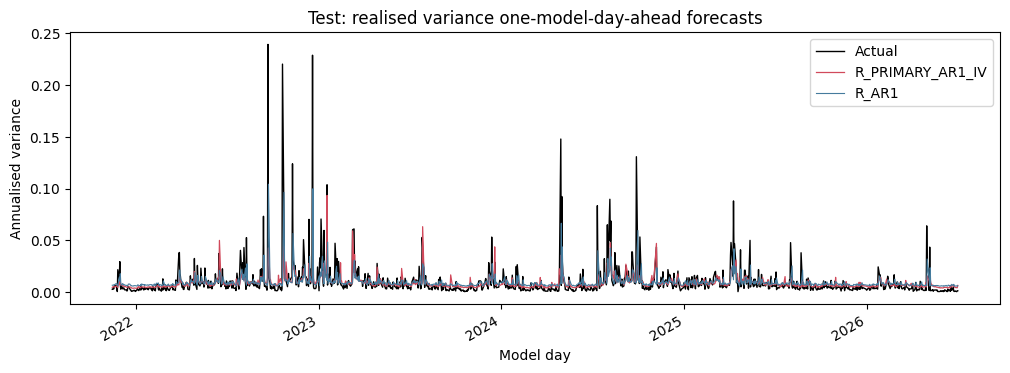

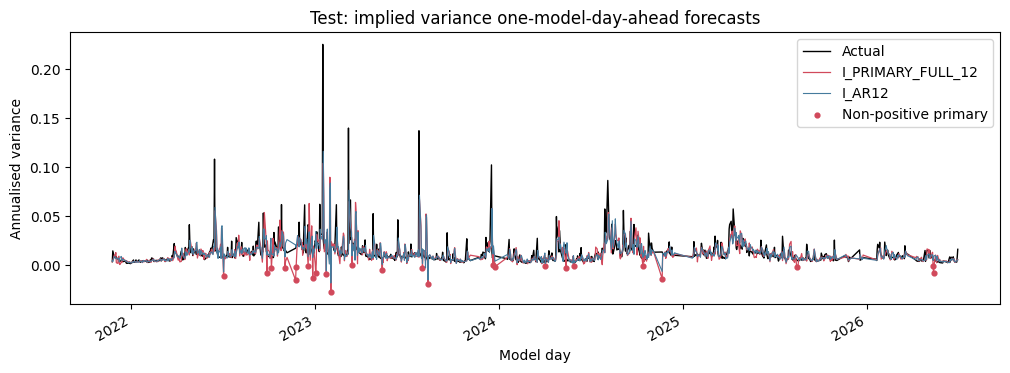

In [43]:
def plot_test(target, primary, benchmark, ylabel):
    f = test_forecasts.loc[(test_forecasts.target.eq(target)) & test_forecasts.model.isin([primary, benchmark])].copy()
    actual = f.drop_duplicates('model_day').set_index('model_day').actual
    piv = f.pivot(index='model_day', columns='model', values='raw_forecast')
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(actual.index, actual, color='black', lw=1.0, label='Actual')
    ax.plot(piv.index, piv[primary], color='#d1495b', lw=.9, label=primary)
    ax.plot(piv.index, piv[benchmark], color='#457b9d', lw=.8, label=benchmark)
    if (piv[primary] <= 0).any(): ax.scatter(piv.index[piv[primary] <= 0], piv.loc[piv[primary] <= 0, primary], color='#d1495b', s=12, label='Non-positive primary')
    ax.set(title=f'Test: {ylabel} one-model-day-ahead forecasts', xlabel='Model day', ylabel='Annualised variance'); ax.legend(); fig.autofmt_xdate(); plt.show()

plot_test('R', 'R_PRIMARY_AR1_IV', 'R_AR1', 'realised variance')
plot_test('I', 'I_PRIMARY_FULL_12', 'I_AR12', 'implied variance')


# Part E - Outputs, integrity status, and downstream denominator validity

Exports retain raw forecasts, residual scales, positive-only QLIKE coverage, and non-positive forecast dates. `exercise_2_complete` records correct calibration/evaluation. `all_primary_background_forecasts_positive` records the separate, stricter fact that every primary background forecast is positive. The retained `ready_for_exercise_3` export field is a backward-compatible alias for that positivity condition; a false value means that some individual ratios are invalid, not that N18 is globally blocked. Downstream event weights proceed wherever the individual counterfactual denominator is strictly positive.

In [44]:
def with_metadata(frame):
    out = frame.copy(); out.insert(0, 'RUN_ID', RUN_ID); out['iv_specification'] = IV_SPECIFICATION; out['iv_column'] = IV_COLUMN
    return out

primary_nonpositive = nonpositive_forecasts.loc[nonpositive_forecasts.model.isin(['R_PRIMARY_AR1_IV', 'I_PRIMARY_FULL_12'])].copy()
primary_r = test_metrics.loc[test_metrics.model.eq('R_PRIMARY_AR1_IV')].iloc[0]
primary_i = test_metrics.loc[test_metrics.model.eq('I_PRIMARY_FULL_12')].iloc[0]
all_primary_background_forecasts_positive = bool(primary_r.positive_fraction == 1.0 and primary_i.positive_fraction == 1.0)
# Compatibility export: False means some individual denominators are invalid, not that N18 is globally blocked.
ready_for_exercise_3 = all_primary_background_forecasts_positive
exercise_2_complete = True
primary_specification = pd.DataFrame([{
    'upstream_notebook16_specification_file': SPEC_PATH.name, 'upstream_notebook16_run_id': spec['RUN_ID'], 'iv_specification': IV_SPECIFICATION, 'iv_column': IV_COLUMN, 'selected_n': N_ORDER, 'selected_m': M_ORDER, 'primary_realised_model': 'R_PRIMARY_AR1_IV', 'primary_implied_model': 'I_PRIMARY_FULL_12', 'retain_Q_to_R': RETAIN['retain_Q_to_R'], 'retain_I_to_R': RETAIN['retain_I_to_R'], 'retain_Q_to_I': RETAIN['retain_Q_to_I'], 'retain_R_to_I': RETAIN['retain_R_to_I'], 'forecast_horizon': 'one_model_day', 'primary_test_protocol': 'fixed_coefficients_after_train_plus_validation', 'expanding_window_role': 'sensitivity', 'event_unaware': CONTRACT_FLAGS['event_unaware'], 'eventless': CONTRACT_FLAGS['eventless'], 'equation_5_implemented': CONTRACT_FLAGS['equation_5_implemented'], 'exercise_2_complete': exercise_2_complete, 'all_primary_background_forecasts_positive': all_primary_background_forecasts_positive, 'ready_for_exercise_3': ready_for_exercise_3
}])
exports = {
    '17_model_comparison_validation.csv': validation_metrics, '17_model_comparison_test.csv': test_metrics,
    '17_coefficients_validation.csv': train_coefficients, '17_coefficients_test.csv': test_coefficients,
    '17_residual_scales.csv': pd.concat([train_scales, test_scales], ignore_index=True),
    '17_forecasts_validation.csv': validation_forecasts, '17_forecasts_test.csv': pd.concat([test_forecasts, expanding_forecasts], ignore_index=True),
    '17_nonpositive_forecasts.csv': nonpositive_forecasts, '17_expanding_window_sensitivity.csv': expanding_sensitivity,
    '17_equation1_diagnostics.csv': equation1_metrics, '17_primary_specification.csv': primary_specification,
}
for name, frame in exports.items():
    out = with_metadata(frame) if name != '17_primary_specification.csv' else frame.assign(RUN_ID=RUN_ID)
    out.to_csv(PROCESSED / name, index=False)
    check = pd.read_csv(PROCESSED / name); assert len(check) == len(out)
assert pd.read_csv(PROCESSED / '17_primary_specification.csv').iloc[0]['iv_column'] == IV_COLUMN
assert RETAIN['retain_Q_to_R'] is False and 'Q_lag1' not in final_fits['R_PRIMARY_AR1_IV']['features']
assert RETAIN['retain_Q_to_I'] and RETAIN['retain_R_to_I']
assert 'Q_lag1' in final_fits['R_EXPANDED_Q_R_IV']['features']
assert set(Q_LAGS + R_LAGS + I_LAGS).issubset(final_fits['I_PRIMARY_FULL_12']['features'])
assert N_ORDER == 1 and M_ORDER == 12
assert set(final_fits['R_PRIMARY_AR1_IV']['sample'].sample_split) == {'train', 'validation'}
assert set(final_fits['I_PRIMARY_FULL_12']['sample'].sample_split) == {'train', 'validation'}
assert final_fits['I_PRIMARY_FULL_12']['sample'].model_day.max() < panel.loc[panel.sample_split.eq('test'), 'model_day'].min()
assert np.allclose(test_forecasts.actual - test_forecasts.raw_forecast, test_forecasts.forecast_error)
assert {'model_day', 'sample_split', 'target', 'model', 'actual', 'raw_forecast', 'forecast_error'}.issubset(test_forecasts.columns)
assert set(exports) == {
    '17_model_comparison_validation.csv',
    '17_model_comparison_test.csv',
    '17_coefficients_validation.csv',
    '17_coefficients_test.csv',
    '17_residual_scales.csv',
    '17_forecasts_validation.csv',
    '17_forecasts_test.csv',
    '17_nonpositive_forecasts.csv',
    '17_expanding_window_sensitivity.csv',
    '17_equation1_diagnostics.csv',
    '17_primary_specification.csv',
}
assert not any('event' in x.lower() for x in sum([v['features'] for v in MODELS.values() if v['features'] is not None], []))
status = {
    'upstream_notebook16_contract_loaded': True, 'iv_specification': IV_SPECIFICATION, 'iv_column': IV_COLUMN, 'selected_n': N_ORDER, 'selected_m': M_ORDER, 'primary_realised_model': 'R_PRIMARY_AR1_IV', 'primary_implied_model': 'I_PRIMARY_FULL_12', 'validation_completed': True, 'fixed_test_completed': True, 'expanding_sensitivity_completed': True, 'equation1_forecast_diagnostics_completed': True, 'realised_primary_nonpositive_test_forecasts': int(primary_r.n_zero_forecasts + primary_r.n_negative_forecasts), 'implied_primary_nonpositive_test_forecasts': int(primary_i.n_zero_forecasts + primary_i.n_negative_forecasts), 'exercise_2_complete': exercise_2_complete, 'all_primary_background_forecasts_positive': all_primary_background_forecasts_positive, 'downstream_ratio_requires_positive_individual_denominator': True, 'notebook_17_ready_to_freeze': exercise_2_complete
}
print(pd.Series(status).to_string())
display(test_metrics)
display(equation1_metrics)


upstream_notebook16_contract_loaded                                       True
iv_specification                                               WEEKDAY_NORM_IV
iv_column                                                         iv_model_var
selected_n                                                                   1
selected_m                                                                  12
primary_realised_model                                        R_PRIMARY_AR1_IV
primary_implied_model                                        I_PRIMARY_FULL_12
validation_completed                                                      True
fixed_test_completed                                                      True
expanding_sensitivity_completed                                           True
equation1_forecast_diagnostics_completed                                  True
realised_primary_nonpositive_test_forecasts                                  0
implied_primary_nonpositive_test_forecasts          

,forecast_scheme,sample_split,target,model,calibration_n,oos_n,MAE,RMSE,mean_error,OOS_R2_vs_persistence,qlike_positive_only,qlike_positive_n,qlike_positive_fraction,qlike_floored_penalty,n_positive_forecasts,n_zero_forecasts,n_negative_forecasts,positive_fraction
0,fixed_train_validation,test,R,R_PERSISTENCE,4186,1182,0.007978,0.021240,0.000006,0.000000,0.794778,1182,1.000000,7.947783e-01,1182,0,0,1.000000
1,fixed_train_validation,test,R,R_AR1,4186,1182,0.006849,0.016870,0.000306,0.369188,0.463711,1182,1.000000,4.637111e-01,1182,0,0,1.000000
2,fixed_train_validation,test,R,R_AR1_Q,4186,1182,0.006862,0.016835,0.000266,0.371757,0.460001,1182,1.000000,4.600014e-01,1182,0,0,1.000000
3,fixed_train_validation,test,R,R_PRIMARY_AR1_IV,4186,1182,0.005551,0.015028,0.001101,0.499442,0.327715,1182,1.000000,3.277145e-01,1182,0,0,1.000000
4,fixed_train_validation,test,R,R_EXPANDED_Q_R_IV,4186,1182,0.005551,0.015003,0.001068,0.501105,0.325666,1182,1.000000,3.256656e-01,1182,0,0,1.000000
5,fixed_train_validation,test,I,I_PERSISTENCE,3313,1071,0.005432,0.015075,0.000007,0.000000,0.159605,1071,1.000000,1.596049e-01,1071,0,0,1.000000
6,fixed_train_validation,test,I,I_AR12,3313,1071,0.005939,0.013363,0.000044,0.214305,0.224093,1065,0.994398,7.544250e+07,1065,0,6,0.994398
7,fixed_train_validation,test,I,I_AR12_Q,3313,1071,0.006315,0.013725,0.000290,0.171092,0.251220,1053,0.983193,1.915104e+08,1053,0,18,0.983193
8,fixed_train_validation,test,I,I_AR12_R,3313,1071,0.006097,0.013476,0.000257,0.200867,0.392536,1054,0.984127,1.632620e+08,1054,0,17,0.984127
9,fixed_train_validation,test,I,I_PRIMARY_FULL_12,3313,1071,0.006476,0.013857,0.000340,0.155036,0.622338,1046,0.976657,3.076879e+08,1046,0,25,0.976657


,sample_split,model,n_forecasts,n_positive_forecasts,n_zero_nonpositive_forecasts,positive_fraction,mu_hat,mu_calibration_n,mean_z,std_z,median_z,skewness_z,excess_kurtosis_z,coverage_68,coverage_95,gaussian_nll
0,validation,R_PRIMARY_AR1_IV,1181,1181,0,1.0,0.000207,3372,-0.038862,0.812884,-0.041031,-0.052267,1.286363,0.806097,0.970364,-4.094961
1,test,R_PRIMARY_AR1_IV,1182,1182,0,1.0,0.000217,4567,0.027633,1.031429,0.097648,-0.542815,1.610680,0.706430,0.938240,-3.749024


## Final N17 summary and downstream hand-off

N17 estimates and evaluates the predictive structure frozen in N16. The primary realised model remains:

$$
R_t
=
c_R
+
\beta_1 R_{t-1}
+
\gamma_1 I_{t-1}
+
\varepsilon_t^R.
$$

The primary implied model remains:

$$
I_t
=
c_I
+
\sum_{j=1}^{12}
\left[
a_j I_{t-j}
+
b_j Q_{t-j}
+
g_j R_{t-j}
\right]
+
\varepsilon_t^I.
$$

Forecasts are one-model-day-ahead and use only lagged information available before the target. VALIDATION is out-of-sample relative to TRAIN coefficient calibration, while still forming part of the wider N16 structure-development process. TRAIN plus VALIDATION then produces the fixed-coefficient TEST forecasts. TEST remains the untouched final evaluation sample and neither selects the predictive structure nor changes the primary models.

**Realised variance.** The realised audit shows that the frozen primary model improves materially over persistence and the own-history benchmark. Its TEST RMSE is about 0.01503, while the expanded Q/R/I sensitivity is about 0.01500. This very small change is consistent with N16's decision not to retain Q history in the primary realised equation. Strong realised forecasting is plausible because volatility is persistent; the lag, calibration, benchmark, fixed-versus-expanding, and innovation audits provide no evidence that the result is mechanically generated by future information. The result remains predictive rather than structural causal evidence.

**Implied variance.** The full 12-lag Q/R/I model beats TEST persistence, but the own-history AR(12) benchmark has a lower aggregate TEST RMSE in the current result (about 0.01336 versus 0.01386). Conditional-GC statistical detectability and aggregate forecast RMSE answer different questions, so this ranking does not reopen the N16 retain/drop decisions.

**Forecast-error diagnostics.** The realised primary TEST standardised innovations are approximately centred and close to unit scale. Empirical 68% and 95% coverages are reasonably close to their Gaussian reference levels, while excess kurtosis documents imperfect tail normality. Fixed estimation remains the primary protocol; expanding estimation remains a sensitivity only.

**Non-positive implied forecasts.** The level-OLS implied equation is unconstrained. The raw TEST audit reports 25 non-positive forecasts among 1,071 primary implied targets in the current canonical result. They are recorded rather than clipped, floored, transformed, or otherwise altered. Where a later event-weight calculation requires a strictly positive counterfactual denominator, those individual ratios are invalid under the existing downstream rule; this does not globally prevent N18 from proceeding.

N17 therefore provides the frozen parametric ordinary-response background for later eventless/event-weight construction. Equation (5) is intentionally excluded from the empirical implementation following Linus's instruction, and N17 does not claim structural causality.